# Grafana Data - Analysis of MockPT Data - From Phase 1 to Phase 3

In [580]:
import pandas as pd
import matplotlib.pyplot as plt


## Network Analysis Functions

In [581]:
# Network Functions

# Function to read Grafana Network CSV File
def read_grafana_network_file(filename):

    # Load Edge and Cloud Network CSV
    target_df = pd.read_csv(filename)

    # Convert timestamp to ms
    target_df['Time'] = pd.to_datetime(target_df['Time'])
    target_df['timestamp_ms'] = (target_df['Time'] - target_df['Time'].min()).dt.total_seconds() * 1000

    # Add sample number
    target_df['sample'] = range(len(target_df))

    # Compute Experiment Time in seconds
    target_df['experiment_time_s'] = target_df['timestamp_ms'] / 1000

    # Convert Network columns to MBit/sec
    for col in target_df.columns:
        target_df[col] = target_df[col].apply(to_mbit_per_sec)

    # Fill NaN values with 0
    target_df = target_df.fillna(0)

    # Return Network Dataframe
    return target_df

# Define a function to convert to MBit/sec from various units
def to_mbit_per_sec(value):
    # Converts string like '1.03 MiB/s', '867 KiB/s', '904 B/s', '10.8 kB/s', '141 MB/s', '141 mB/s' to MBit/sec
    if isinstance(value, str):
        v = value.strip()
        v_lower = v.lower()
        try:
            if 'mib/s' in v_lower:
                return float(v_lower.replace(' mib/s', '')) * 8.388608
            elif 'mb/s' in v_lower:
                return float(v_lower.replace(' mb/s', '')) * 8
            elif 'kib/s' in v_lower:
                return float(v_lower.replace(' kib/s', '')) * 0.008192
            elif 'kb/s' in v_lower:
                return float(v_lower.replace(' kb/s', '')) * 0.008
            elif 'b/s' in v_lower:
                return float(v_lower.replace(' b/s', '')) * 8 / 1_000_000
            else:
                return 0.0
        except Exception:
            return 0.0
    try:
        return float(value)
    except Exception:
        return 0.0

# Define a function to convert to Kbit / sec from various units
def to_kbit_per_sec(value):
    # Use the above function and convert MBit to KBit
    mbit = to_mbit_per_sec(value)
    return mbit * 1000

## Memory Analysis Functions

In [582]:
# Function to read Grafana Memory CSV File
def read_grafana_memory_file(filename):

    # Load Edge and Cloud Network CSV
    target_df = pd.read_csv(filename)

    # Convert timestamp to ms
    target_df['Time'] = pd.to_datetime(target_df['Time'])
    target_df['timestamp_ms'] = (target_df['Time'] - target_df['Time'].min()).dt.total_seconds() * 1000

    # Add sample number
    target_df['sample'] = range(len(target_df))

    # Compute Experiment Time in seconds
    target_df['experiment_time_s'] = target_df['timestamp_ms'] / 1000

    # Convert Network columns to MBit/sec
    for col in target_df.columns:
        target_df[col] = target_df[col].apply(memory_to_mbit)

    # Fill NaN values with 0
    target_df = target_df.fillna(0)

    # Return Network Dataframe
    return target_df

# Convert memory usage to MBit
def memory_to_mbit(value):
    # Converts string like '1.03 MiB', '867 KiB', '904 B', '10.8 kB', '141 MB', '141 mB' to MBit , 1.32 GiB to MBit
    if isinstance(value, str):
        v = value.strip()
        v_lower = v.lower()
        try:
            if 'mib' in v_lower:
                return float(v_lower.replace(' mib', '')) * 8.388608
            elif 'mb' in v_lower:
                return float(v_lower.replace(' mb', '')) * 8
            elif 'kib' in v_lower:
                return float(v_lower.replace(' kib', '')) * 0.008192
            elif 'kb' in v_lower:
                return float(v_lower.replace(' kb', '')) * 0.008
            elif 'gib' in v_lower:
                return float(v_lower.replace(' gib', '')) * 8589.934592
            elif 'gb' in v_lower:
                return float(v_lower.replace(' gb', '')) * 8000
            elif 'b' in v_lower:
                return float(v_lower.replace(' b', '')) * 8 / 1_000_000
            else:
                return 0.0
        except Exception as e:
            print("Error converting memory value:", e)
            return 0.0
    try:
        return float(value)
    except Exception:
        return 0.0

def memory_to_megabytes(value):
    # Use the above function and convert MBit to MB
    mbit = memory_to_mbit(value)
    return mbit / 8

## CPU Analysis Function

In [583]:
# Read CPU CSV File
def read_grafana_cpu_file(filename):

    # Load Edge and Cloud CPU CSV
    target_df = pd.read_csv(filename)

    # Convert timestamp to ms
    target_df['Time'] = pd.to_datetime(target_df['Time'])
    target_df['timestamp_ms'] = (target_df['Time'] - target_df['Time'].min()).dt.total_seconds() * 1000

    # Add sample number
    target_df['sample'] = range(len(target_df))

    # Compute Experiment Time in seconds
    target_df['experiment_time_s'] = target_df['timestamp_ms'] / 1000

    # Convert % columns to float
    for col in target_df.columns:
        if target_df[col].dtype == object and target_df[col].str.endswith('%').any():
            target_df[col] = target_df[col].str.rstrip('%').astype(float)

    # Fill NaN values with 0
    target_df = target_df.fillna(0)

    # Return CPU Dataframe
    return target_df


## Filtering & Renaming Functions

In [584]:
# Filter by container name and sample range
def filter_by_container_name_list(target_df, container_name_list):
    # Filter columns
    target_df = target_df[['timestamp_ms', 'experiment_time_s', 'sample'] + container_name_list]

    # Focus on samples between 100 and 400
    #df_ditto = df_ditto[(df_ditto['sample'] >= 100) & (df_ditto['sample'] <= 400)]

    return target_df


## Load CPU, Network In/Out and Memory Data

In [585]:
# Target Container List
target_container_list = [
    'mockpt-opcua-mqtt-client',
    'physical_twin_emulator'
]

# Experiment Phases
phases = ['phase-1', 'phase-2', 'phase-3']

# Dictionary to hold DataFrames for each phase for each type of data
phase_data_frames = {}

# Loop through experiment phases
for experiment_phase in phases:

    # Read CPU CSV File
    target_cpu_file_path = f'data/{experiment_phase}/cpu.csv'

    # Load Edge and Cloud CPU CSV
    cpu_df = read_grafana_cpu_file(target_cpu_file_path)

    # Read Network In CSV File
    target_network_in_file_path = f'data/{experiment_phase}/net_in.csv'
    print("Loading Network In data from:", target_network_in_file_path)

    # Read Network Data
    net_in_df = read_grafana_network_file(target_network_in_file_path)

    # Filter by target container list
    net_in_df = filter_by_container_name_list(net_in_df, target_container_list)

    # Read Network Out CSV File
    target_network_out_file_path = f'data/{experiment_phase}/net_out.csv'
    print("Loading Network Out data from:", target_network_out_file_path)

    # Read Network Data
    net_out_df = read_grafana_network_file(target_network_out_file_path)

    # Filter by target container list
    net_out_df = filter_by_container_name_list(net_out_df, target_container_list)

    # Read Memory CSV File
    target_memory_file_path = f'data/{experiment_phase}/memory.csv'
    print("Loading Memory data from:", target_memory_file_path)

    # Read Memory Data
    memory_df = read_grafana_memory_file(target_memory_file_path)

    # Filter by target container list
    memory_df = filter_by_container_name_list(memory_df, target_container_list)

    # Convert memory from MBit to MBytes
    for container in target_container_list:
        memory_df[container] = memory_df[container].apply(lambda x: x / 8)

    # Store DataFrames in dictionary
    phase_data_frames[experiment_phase] = {
        'cpu': cpu_df,
        'net_in': net_in_df,
        'net_out': net_out_df,
        'memory': memory_df
    }


Loading Network In data from: data/phase-1/net_in.csv
Loading Network Out data from: data/phase-1/net_out.csv
Loading Memory data from: data/phase-1/memory.csv
Loading Network In data from: data/phase-2/net_in.csv
Loading Network Out data from: data/phase-2/net_out.csv
Loading Memory data from: data/phase-2/memory.csv
Loading Network In data from: data/phase-3/net_in.csv
Loading Network Out data from: data/phase-3/net_out.csv
Loading Memory data from: data/phase-3/memory.csv


## Integrated Graph: CPU, Network In/Out, Memory

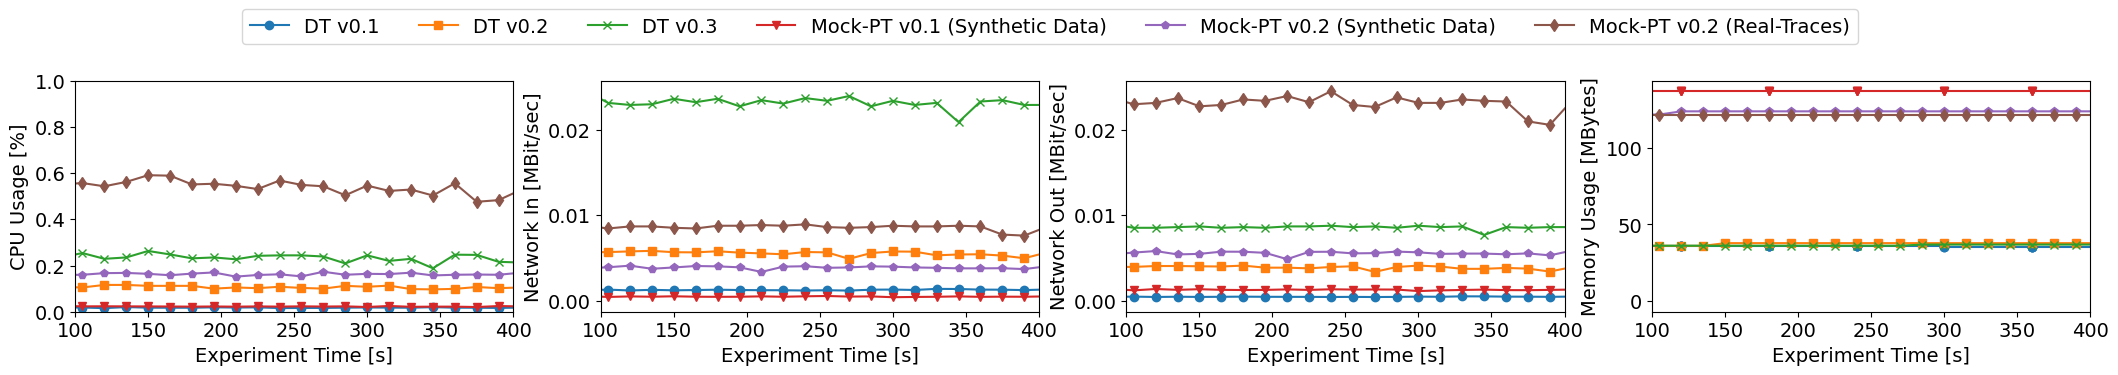

In [586]:
# Increase font size for better readability
plt.rcParams.update({'font.size': 14})

# Create a 1 row, 4 column subplots
fig, axs = plt.subplots(1, 4, figsize=(26, 3))

# Set Data Labels
data_labels = {
    "phase-1": {
        'mockpt-opcua-mqtt-client': {
            "name": 'DT v0.1',
            "line_style": '-',
            "marker": 'o'
        },
        'physical_twin_emulator': {
            'name': 'Mock-PT v0.1 (Synthetic Data)',
            'line_style': '-',
            "marker": 'v'
        }
    },
    "phase-2": {
        'mockpt-opcua-mqtt-client': {
            'name': 'DT v0.2',
            'line_style': '-',
            "marker": 's'
        },
        'physical_twin_emulator': {
            'name': 'Mock-PT v0.2 (Synthetic Data)',
            'line_style': '-',
            "marker": 'p'
        }
    },
    "phase-3": {
        'mockpt-opcua-mqtt-client': {
            'name': 'DT v0.3',
            'line_style': '-',
            "marker": 'x'
        },
        'physical_twin_emulator': {
            'name': 'Mock-PT v0.2 (Real-Traces)',
            'line_style': '-',
            "marker": 'd'
        }
    }

}

# Plot CPU for each experiment phase in the same graph
for container in target_container_list:
    for experiment_phase in phases:
        cpu_df = phase_data_frames[experiment_phase]['cpu']
        axs[0].plot(cpu_df['experiment_time_s'], cpu_df[container],
                    label=data_labels[experiment_phase][container]['name'],
                    linestyle=data_labels[experiment_phase][container]['line_style'],
                    marker=data_labels[experiment_phase][container]['marker'])

axs[0].set_xlabel('Experiment Time [s]')
axs[0].set_ylabel('CPU Usage [%]')
#axs[0].set_title('Containers CPU Usage Over Time')
axs[0].set_ylim(0, 1)
axs[0].set_xlim(100, 400)
#axs[0].legend()

# Plot Network In
for container in target_container_list:
    for experiment_phase in phases:
        net_in_df = phase_data_frames[experiment_phase]['net_in']
        axs[1].plot(net_in_df['experiment_time_s'], net_in_df[container],
                    linestyle=data_labels[experiment_phase][container]['line_style'],
                    marker=data_labels[experiment_phase][container]['marker'])

axs[1].set_xlabel('Experiment Time [s]')
axs[1].set_ylabel('Network In [MBit/sec]')
#axs[1].set_title('Containers Network In Over Time')
axs[1].set_xlim(100, 400)
#axs[1].legend()

# Plot Network Out
for container in target_container_list:
    for experiment_phase in phases:
        net_out_df = phase_data_frames[experiment_phase]['net_out']
        axs[2].plot(net_out_df['experiment_time_s'], net_out_df[container],
                    linestyle=data_labels[experiment_phase][container]['line_style'],
                    marker=data_labels[experiment_phase][container]['marker'])

axs[2].set_xlabel('Experiment Time [s]')
axs[2].set_ylabel('Network Out [MBit/sec]')
#axs[2].set_title('Containers Network Out Over Time')
axs[2].set_xlim(100, 400)
#axs[2].legend()

# Plot Memory
for container in target_container_list:
    for experiment_phase in phases:
        memory_df = phase_data_frames[experiment_phase]['memory']
        axs[3].plot(memory_df['experiment_time_s'], memory_df[container],
                    linestyle=data_labels[experiment_phase][container]['line_style'],
                    marker=data_labels[experiment_phase][container]['marker'])

axs[3].set_xlabel('Experiment Time [s]')
axs[3].set_ylabel('Memory Usage [MBytes]')
#axs[3].set_title('Containers Memory Usage Over Time')
axs[3].set_xlim(100, 400)
#axs[3].legend()

# Put Legend outside the plots
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=6)

# Save the figure with high resolution
plt.savefig(f'graph/phases_1_2_3_integrated_graph.pdf', dpi=300, bbox_inches='tight')

plt.show()

## Individual Graphs for MockPT and DT

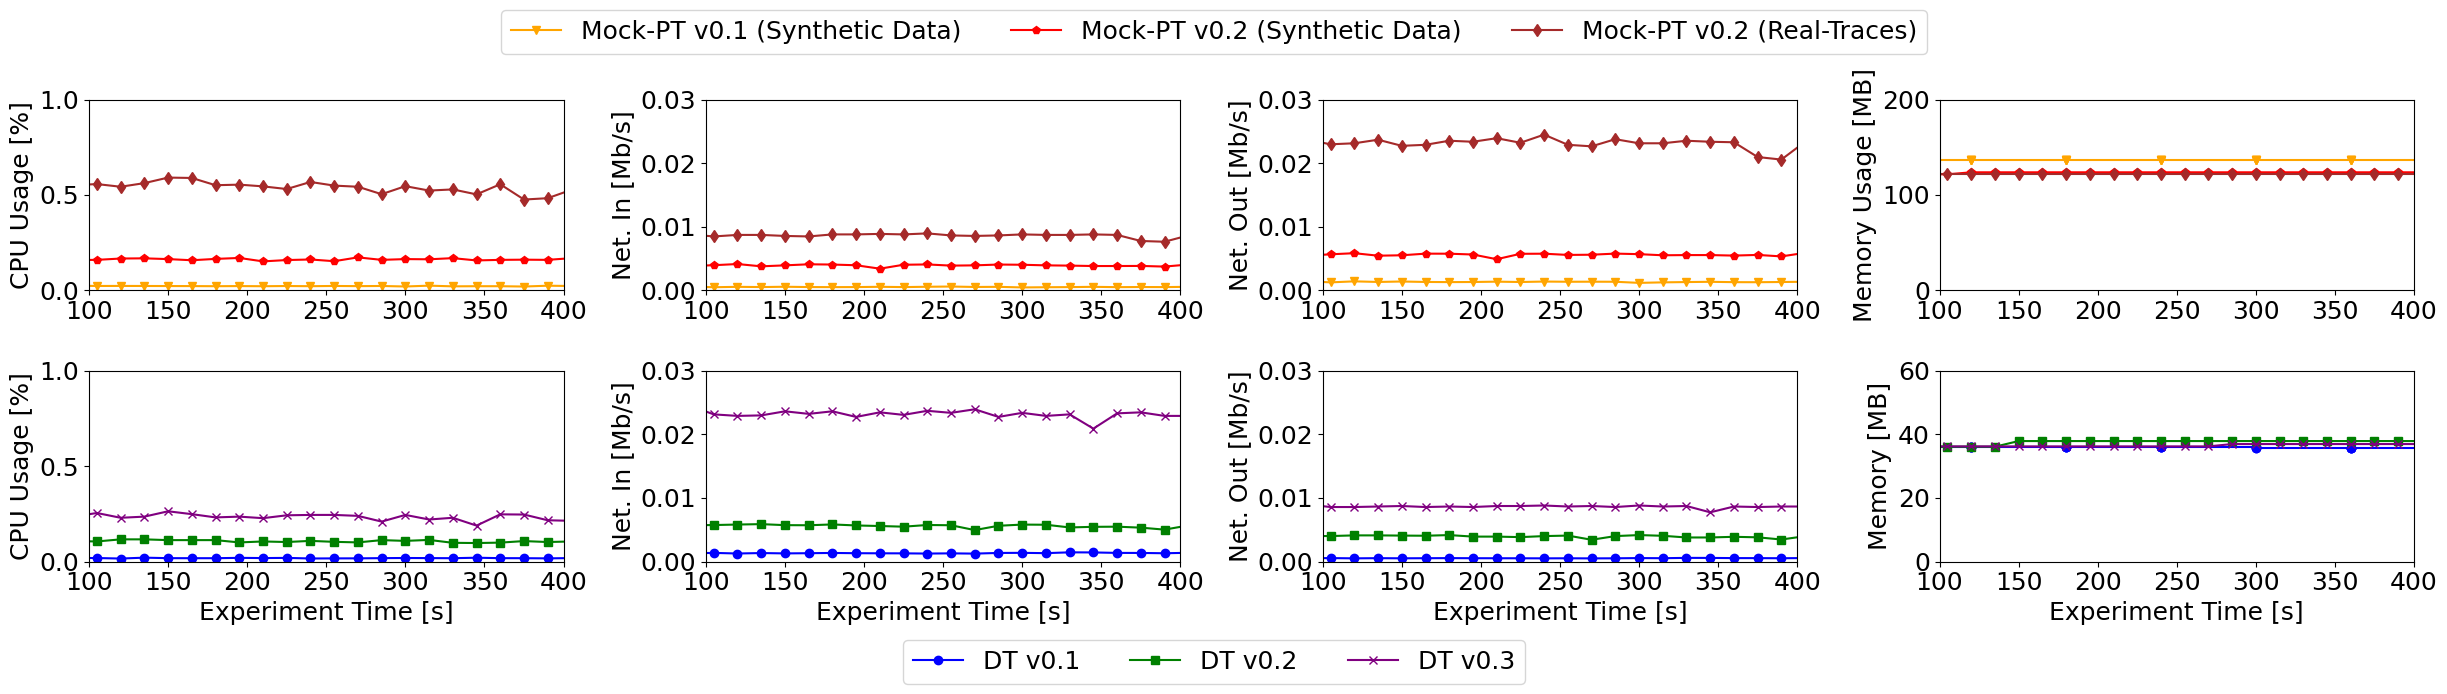

In [587]:
# Increase font size for better readability
plt.rcParams.update({'font.size': 18})

# Create a 1 row, 4 column subplots
fig, axs = plt.subplots(2, 4, figsize=(30, 6))

# Adjust vertical space between subplots
fig.subplots_adjust(hspace=0.42)

# Adjust horizontal space between subplots
fig.subplots_adjust(wspace=0.3)

# Set Data Labels
data_labels = {
    "phase-1": {
        'mockpt-opcua-mqtt-client': {
            "name": 'DT v0.1',
            "line_style": '-',
            "marker": 'o',
            "color": 'blue'
        },
        'physical_twin_emulator': {
            'name': 'Mock-PT v0.1 (Synthetic Data)',
            'line_style': '-',
            "marker": 'v',
            "color": 'orange'
        }
    },
    "phase-2": {
        'mockpt-opcua-mqtt-client': {
            'name': 'DT v0.2',
            'line_style': '-',
            "marker": 's',
            "color": 'green'

        },
        'physical_twin_emulator': {
            'name': 'Mock-PT v0.2 (Synthetic Data)',
            'line_style': '-',
            "marker": 'p',
            "color": 'red'
        }
    },
    "phase-3": {
        'mockpt-opcua-mqtt-client': {
            'name': 'DT v0.3',
            'line_style': '-',
            "marker": 'x',
            "color": 'purple'
        },
        'physical_twin_emulator': {
            'name': 'Mock-PT v0.2 (Real-Traces)',
            'line_style': '-',
            "marker": 'd',
            "color": 'brown'
        }
    }

}

mockpt_labels = []
dt_labels = []

mockpt_handles = []
dt_handles = []

# Plot CPU for each experiment phase in the same graph
for experiment_phase in phases:
    cpu_df = phase_data_frames[experiment_phase]['cpu']

    mockpt_line, = axs[0,0].plot(cpu_df['experiment_time_s'], cpu_df['physical_twin_emulator'],
             label=data_labels[experiment_phase]['physical_twin_emulator']['name'],
             linestyle=data_labels[experiment_phase]['physical_twin_emulator']['line_style'],
             marker=data_labels[experiment_phase]['physical_twin_emulator']['marker'],
             color=data_labels[experiment_phase]['physical_twin_emulator']['color'])

    dt_line, = axs[1,0].plot(cpu_df['experiment_time_s'], cpu_df['mockpt-opcua-mqtt-client'],
             label=data_labels[experiment_phase]['mockpt-opcua-mqtt-client']['name'],
             linestyle=data_labels[experiment_phase]['mockpt-opcua-mqtt-client']['line_style'],
             marker=data_labels[experiment_phase]['mockpt-opcua-mqtt-client']['marker'],
             color=data_labels[experiment_phase]['mockpt-opcua-mqtt-client']['color'])

    mockpt_handles.append(mockpt_line)
    dt_handles.append(dt_line)

    dt_labels.append(data_labels[experiment_phase]['mockpt-opcua-mqtt-client']['name'])
    mockpt_labels.append(data_labels[experiment_phase]['physical_twin_emulator']['name'])


    axs[0,0].set_ylabel('CPU Usage [%]')
    axs[0,0].set_ylim(0, 1)
    axs[0,0].set_xlim(100, 400)
    axs[1,0].set_xlabel('Experiment Time [s]')
    axs[1,0].set_ylabel('CPU Usage [%]')
    axs[1,0].set_ylim(0, 1)
    axs[1,0].set_xlim(100, 400)

# Plot Network In
for experiment_phase in phases:
    net_in_df = phase_data_frames[experiment_phase]['net_in']

    mockpt_line, = axs[0,1].plot(net_in_df['experiment_time_s'], net_in_df['physical_twin_emulator'],
             label=data_labels[experiment_phase]['physical_twin_emulator']['name'],
             linestyle=data_labels[experiment_phase]['physical_twin_emulator']['line_style'],
             marker=data_labels[experiment_phase]['physical_twin_emulator']['marker'],
             color=data_labels[experiment_phase]['physical_twin_emulator']['color'])

    dt_line, = axs[1,1].plot(net_in_df['experiment_time_s'], net_in_df['mockpt-opcua-mqtt-client'],
             label=data_labels[experiment_phase]['mockpt-opcua-mqtt-client']['name'],
             linestyle=data_labels[experiment_phase]['mockpt-opcua-mqtt-client']['line_style'],
             marker=data_labels[experiment_phase]['mockpt-opcua-mqtt-client']['marker'],
             color=data_labels[experiment_phase]['mockpt-opcua-mqtt-client']['color'])

    axs[0,1].set_ylabel('Net. In [Mb/s]')
    axs[0,1].set_xlim(100, 400)
    axs[0,1].set_ylim(0, 0.03)
    axs[1,1].set_xlabel('Experiment Time [s]')
    axs[1,1].set_ylabel('Net. In [Mb/s]')
    axs[1,1].set_xlim(100, 400)
    axs[1,1].set_ylim(0, 0.03)

# Plot Network Out
for experiment_phase in phases:
    net_out_df = phase_data_frames[experiment_phase]['net_out']

    mockpt_line, = axs[0,2].plot(net_out_df['experiment_time_s'], net_out_df['physical_twin_emulator'],
             label=data_labels[experiment_phase]['physical_twin_emulator']['name'],
             linestyle=data_labels[experiment_phase]['physical_twin_emulator']['line_style'],
             marker=data_labels[experiment_phase]['physical_twin_emulator']['marker'],
             color=data_labels[experiment_phase]['physical_twin_emulator']['color'])

    dt_line, = axs[1,2].plot(net_out_df['experiment_time_s'], net_out_df['mockpt-opcua-mqtt-client'],
             label=data_labels[experiment_phase]['mockpt-opcua-mqtt-client']['name'],
             linestyle=data_labels[experiment_phase]['mockpt-opcua-mqtt-client']['line_style'],
             marker=data_labels[experiment_phase]['mockpt-opcua-mqtt-client']['marker'],
             color=data_labels[experiment_phase]['mockpt-opcua-mqtt-client']['color'])

    axs[0,2].set_ylabel('Net. Out [Mb/s]')
    axs[0,2].set_xlim(100, 400)
    axs[0,2].set_ylim(0, 0.03)
    axs[1,2].set_xlabel('Experiment Time [s]')
    axs[1,2].set_ylabel('Net. Out [Mb/s]')
    axs[1,2].set_xlim(100, 400)
    axs[1,2].set_ylim(0, 0.03)

# Plot Memory
for experiment_phase in phases:
    memory_df = phase_data_frames[experiment_phase]['memory']

    mockpt_line, = axs[0,3].plot(memory_df['experiment_time_s'], memory_df['physical_twin_emulator'],
             label=data_labels[experiment_phase]['physical_twin_emulator']['name'],
             linestyle=data_labels[experiment_phase]['physical_twin_emulator']['line_style'],
             marker=data_labels[experiment_phase]['physical_twin_emulator']['marker'],
             color=data_labels[experiment_phase]['physical_twin_emulator']['color'])

    dt_line, = axs[1,3].plot(memory_df['experiment_time_s'], memory_df['mockpt-opcua-mqtt-client'],
             label=data_labels[experiment_phase]['mockpt-opcua-mqtt-client']['name'],
             linestyle=data_labels[experiment_phase]['mockpt-opcua-mqtt-client']['line_style'],
             marker=data_labels[experiment_phase]['mockpt-opcua-mqtt-client']['marker'],
             color=data_labels[experiment_phase]['mockpt-opcua-mqtt-client']['color'])

    axs[0,3].set_ylabel('Memory Usage [MB]')
    axs[0,3].set_xlim(100, 400)
    axs[0,3].set_ylim(0, 200)
    axs[1,3].set_xlabel('Experiment Time [s]')
    axs[1,3].set_ylabel('Memory [MB]')
    axs[1,3].set_xlim(100, 400)
    axs[1,3].set_ylim(0, 60)

# Put Legend outside the plots
handles, labels = axs[0,0].get_legend_handles_labels()

# Add legend for both rows
fig.legend(mockpt_handles, mockpt_labels, loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=len(mockpt_labels))
fig.legend(dt_handles, dt_labels, loc='upper center', bbox_to_anchor=(0.5, -0.0), ncol=len(dt_labels))


# Save the figure with high resolution
plt.savefig(f'graph/phases_1_2_3_integrated_graph.pdf', dpi=300, bbox_inches='tight')

plt.show()